In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris                 # the built-in Iris dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler       # to put features on the same scale
from sklearn.linear_model import LogisticRegression    # the logistic regression model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Imported")

Imported


In [14]:
iris = load_iris(as_frame=True)

X = iris.data                        # input features (measurements)
y = iris.target                      # 0, 1, or 2 (which species)
class_names = iris.target_names      # ['setosa','versicolor','virginica']

# Rename the columns
X.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

print("Feature columns:", list(X.columns))
print("Classes (species):", list(class_names))
print("Data shape:", X.shape, "  (150 flowers, 4 measurements each)")

Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Classes (species): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Data shape: (150, 4)   (150 flowers, 4 measurements each)


In [15]:
# Combine features + labels
preview = X.copy()
preview["species"] = [class_names[i] for i in y]   # turn 0/1/2 into names
print(preview.head())

# class balance
print("\nHow many of each species:")
print(preview["species"].value_counts())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

How many of each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


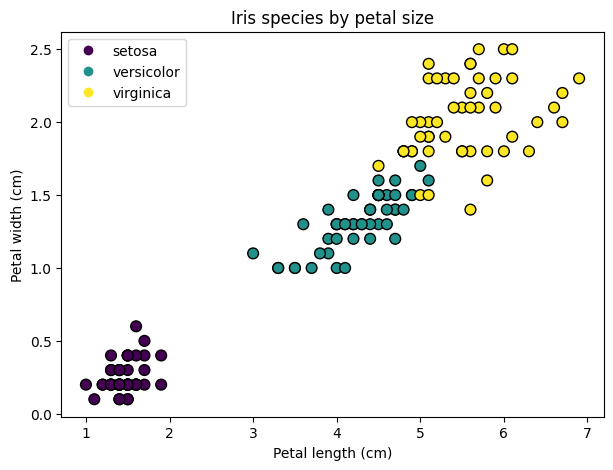

In [19]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(X["petal_length"], X["petal_width"], c=y, cmap="viridis", edgecolor="k", s=60)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris species by petal size")
plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names))
plt.show()

In [20]:
# Split for Train | Test
# stratify=y keeps the same species proportions in both parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Scale features: make each measurement have mean 0 and standard deviation 1.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 120
Testing samples : 30


#Multinomial Logistic Regression (Softmax)

One model that predicts all 3 species probabilities together

MULTINOMIAL accuracy: 0.9333

Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



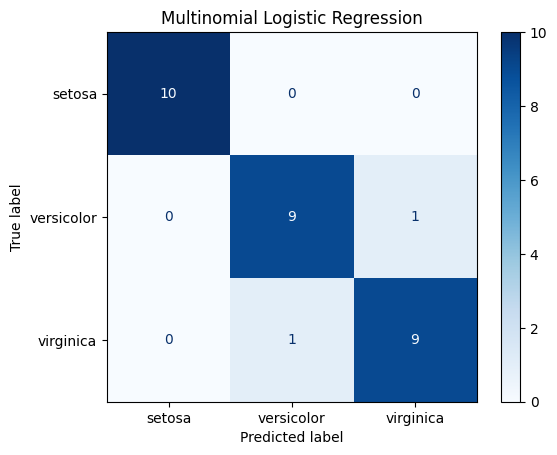

In [22]:
# Create and train the 'Multinomial model'.
multinomial_model = LogisticRegression(max_iter=1000, random_state=42)
multinomial_model.fit(X_train, y_train)

# prediction
y_pred_multi = multinomial_model.predict(X_test)

acc_multi = accuracy_score(y_test, y_pred_multi)
print("MULTINOMIAL accuracy:", round(acc_multi, 4))
print("\nReport:")
print(classification_report(y_test, y_pred_multi, target_names=class_names))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_multi), display_labels=class_names).plot(cmap="Blues")
plt.title("Multinomial Logistic Regression")
plt.show()

#OvR (One-vs-Rest) Logistic Regression

Here we wrap the same model in OneVsRestClassifier, which automatically builds one classifier per species.

OvR (One-vs-Rest) accuracy: 0.9

Detailed report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



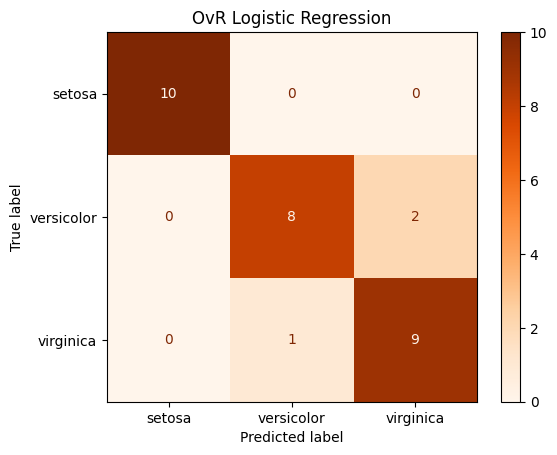

In [23]:
# Wrap a LogisticRegression inside OneVsRestClassifier.
# trains 3 separate "this species vs everything else" classifiers.
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr_model.fit(X_train, y_train)

# Predict
y_pred_ovr = ovr_model.predict(X_test)

# Measure performance
acc_ovr = accuracy_score(y_test, y_pred_ovr)
print("OvR (One-vs-Rest) accuracy:", round(acc_ovr, 4))
print("\nDetailed report:")
print(classification_report(y_test, y_pred_ovr, target_names=class_names))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ovr), display_labels=class_names).plot(cmap="Oranges")
plt.title("OvR Logistic Regression")
plt.show()

#Peek inside OvR to see the 3 separate classifiers

3 little models bundled together.

In [24]:
# OvR stores its individual classifiers in .estimators_
print("Number of internal classifiers:", len(ovr_model.estimators_))
print("(One binary classifier per species)\n")

for i, estimator in enumerate(ovr_model.estimators_):
    print(f"Classifier #{i+1}: '{class_names[i]}' vs the rest")

Number of internal classifiers: 3
(One binary classifier per species)

Classifier #1: 'setosa' vs the rest
Classifier #2: 'versicolor' vs the rest
Classifier #3: 'virginica' vs the rest


#Compare the probabilities for a single flower

How differently the two methods assign confidence. Multinomial probabilities are balanced against each other (softmax); OvR gets each class's probability separately.

In [25]:
# Take the first flower in the test set
sample = X_test[0:1]                     # keep it 2D for the model
true_label = class_names[y_test.iloc[0]] if hasattr(y_test, "iloc") else class_names[y_test[0]]

print("True species of this flower:", true_label, "\n")

# probability for each of the 3 species
probs_multi = multinomial_model.predict_proba(sample)[0]
probs_ovr   = ovr_model.predict_proba(sample)[0]

print(f"{'Species':<12}{'Multinomial':>14}{'OvR':>10}")
for name, pm, po in zip(class_names, probs_multi, probs_ovr):
    print(f"{name:<12}{pm:>14.3f}{po:>10.3f}")

True species of this flower: setosa 

Species        Multinomial       OvR
setosa               0.979     0.774
versicolor           0.021     0.226
virginica            0.000     0.000


In [26]:
print("RESULTS")
print(f"Multinomial (Softmax) accuracy : {acc_multi:.4f}")
print(f"OvR (One-vs-Rest)     accuracy : {acc_ovr:.4f}")

RESULTS
Multinomial (Softmax) accuracy : 0.9333
OvR (One-vs-Rest)     accuracy : 0.9000


Multinomial usually better on this dataset because it optimises all classes jointly instead of one-at-a-time.

#Visualize the decision boundaries

Draws the regions each model assigns to each species, using just petal length and width so it fits in 2D.

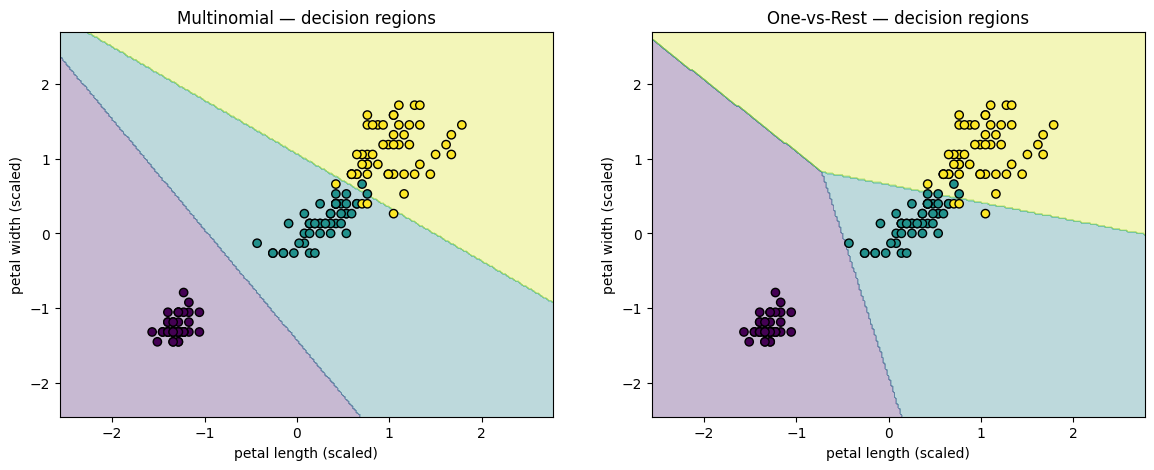

In [27]:
# Use only 2 features so we can plot in 2D
X2 = X[["petal_length", "petal_width"]].values
sc2 = StandardScaler()
X2s = sc2.fit_transform(X2)

# Train both models on these 2 features
m_multi = LogisticRegression(max_iter=1000, random_state=42).fit(X2s, y)
m_ovr   = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X2s, y)

# Build a grid of points covering the whole plot area
x_min, x_max = X2s[:,0].min()-1, X2s[:,0].max()+1
y_min, y_max = X2s[:,1].min()-1, X2s[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
grid = np.c_[xx.ravel(), yy.ravel()]     # every point on the grid

# Draw both side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, model, title in [(axes[0], m_multi, "Multinomial"),
                         (axes[1], m_ovr,   "One-vs-Rest")]:
    Z = model.predict(grid).reshape(xx.shape)     # predict species for each grid point
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")   # colour the regions
    ax.scatter(X2s[:,0], X2s[:,1], c=y, edgecolor="k", cmap="viridis")  # real flowers
    ax.set_title(f"{title} — decision regions")
    ax.set_xlabel("petal length (scaled)")
    ax.set_ylabel("petal width (scaled)")
plt.show()